In [2]:

import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import math
import scipy.stats as stats
import corner
import emcee
import random
# # import  settings
import plot_settings
plot_settings.apply()


import importlib
import sim_PyBaMM
importlib.reload(sim_PyBaMM)

<module 'sim_PyBaMM' from '/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/sim_PyBaMM.py'>

In [22]:
a = [3.8194,-4.6554,-8.901,19.3256,-11.956,3.2912, 3.2518]


a = a[::-1] 

i0 = 1.5


Q = 2400 
tf = Q / i0
t = np.linspace(0, tf, 100)

def dirac_delta(t):
    return np.where(t == 0, 1, 0)

def terms(n,t,a=a, i0=i0, Q=Q):
    n = n
    m = 2 * n -1 
    return a[n] * (i0/Q)**n * t**m / math.factorial(m)

t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0)

params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 6)
p = np.poly1d(params)

def V_soc(SOC,p=p):
    return  p(SOC)


def Z(R1, C1, t):
    return R1 * (1 - np.exp(-t / (R1 * C1)))

def simulate(R0, R1, C1,R2,C2, i0 = i0,t = t):
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t) + Z(R2, C2, t)) 

    return t, U

def simulate_I(R1,R2, C1,C2, i0 = i0,t = t):
    R0 = 0.1
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t) + Z(R2, C2, t)) 
    return t, U

def simulate_II(R1, C1, i0 = i0,t = t):
    R0 = 0.1
    U = V_soc(SOC(i0)) - i0*(R0 + Z(R1, C1, t))
    return t, U


def SOC(i0, Q = Q):
    t = np.linspace(0, Q/i0, 100)
    z = 1 - i0 * t / Q
    return z



R1 = 0.01

R2 = 0.01


C1 = 100
C2 = 100
R0 = 0.075

#plt.plot(SOC(i0),V_soc(a), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))
#plt.plot(t,SOC(i0, t, Q), label = 'R0 = {}, R1 = {}, C = {}'.format(R0, R1, C))


Text(0, 0.5, 'Voltage [V]')

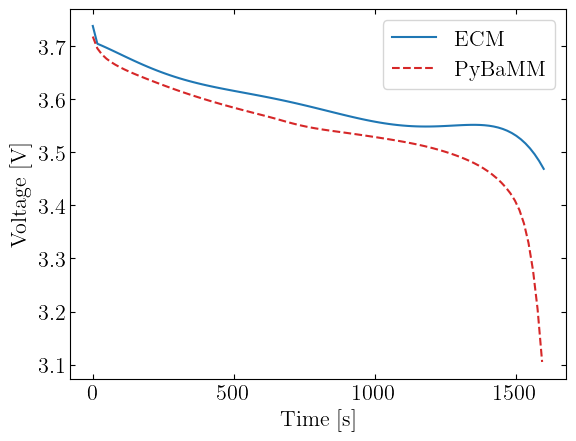

In [4]:
plt.plot(*simulate(R0, R1, C1,R2,C2), label = 'ECM')
plt.plot(*sim_PyBaMM.get_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')

<Figure size 640x480 with 0 Axes>

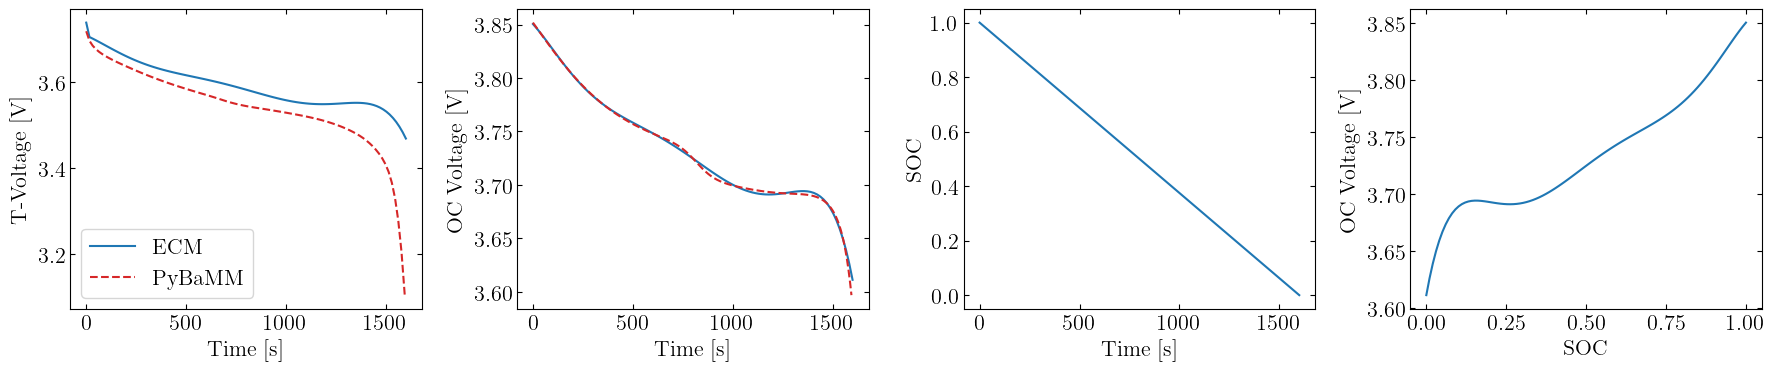

In [5]:
plt.figure()

fig, ax = plt.subplots(1,4, figsize = (18,4))

ax[0].plot(*simulate(R0, R1, C1,R2,C2), label = 'ECM')
ax[0].plot(*sim_PyBaMM.get_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[0].legend()
ax[1].plot(t,V_soc(SOC(i0)) )
ax[1].plot(*sim_PyBaMM.get_OC_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
ax[2].plot(t, SOC(i0,))
ax[3].plot(SOC(i0),V_soc(SOC(i0)))
ax[0].set_xlabel('Time [s]')
ax[0].set_ylabel('T-Voltage [V]')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('OC Voltage [V]')
ax[2].set_xlabel('Time [s]')
ax[2].set_ylabel('SOC')
ax[3].set_xlabel('SOC')
ax[3].set_ylabel('OC Voltage [V]')
plt.tight_layout()


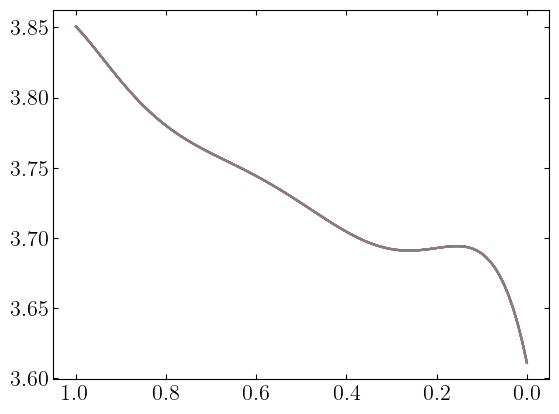

In [6]:
for i in np.arange(2,10):
    i /= 4
    plt.plot(SOC(i),V_soc(SOC(i)))
    # inverting x-axis to match the typical SOC-OCV curve orientation

plt.gca().invert_xaxis()
    #plt.plot(*sim_PyBaMM.get_OC_voltage(i), label = 'PyBaMM', linestyle = '--',color = 'tab:red')

[-18.55534574  63.3746161  -83.98589518  54.26142329 -17.38212651
   2.57970588   3.55535818]


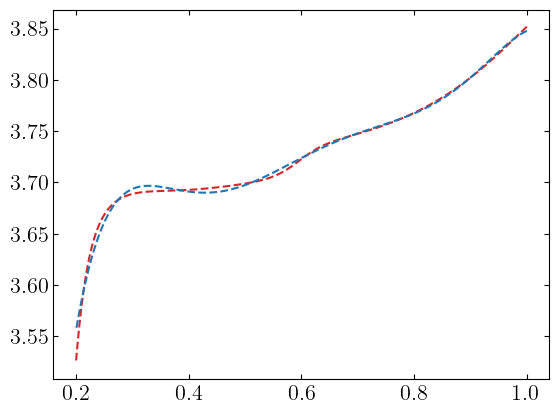

In [7]:
i0 = 1
t_oc,V_oc = sim_PyBaMM.get_OC_voltage(i0)
params = np.polyfit(np.linspace(1,0,len(t_oc)), V_oc, 6)
p = np.poly1d(params)
print(params)
plt.plot(np.linspace(1,0.2,len(t_oc)), V_oc, label = 'PyBaMM OC Voltage', linestyle = '--',color = 'tab:red')
plt.plot(np.linspace(1,0.2,len(t_oc)), p(np.linspace(1,0,len(t_oc))), label = 'Fitted OC Voltage', linestyle = '--',color = 'tab:blue')


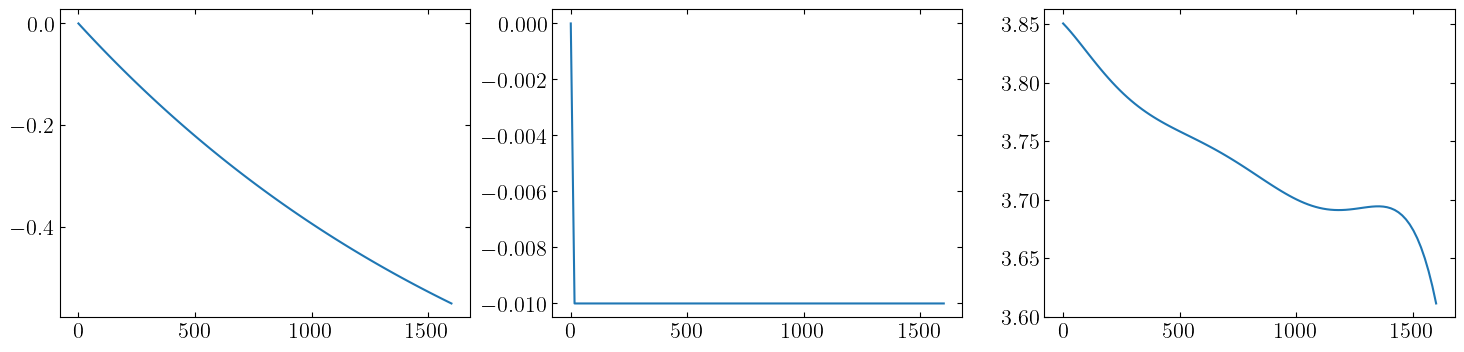

In [8]:
fig, ax = plt.subplots(1,3, figsize = (18,4))
R1 = 1
C1 = 2000
ax[0].plot(t,-i0 * (Z(R1, C1, t)), label = 'Z_1')
ax[1].plot(t,-i0 * (Z(R2, C2, t)), label = 'Z_2')
ax[2].plot(t,V_soc(SOC(i0)), label = 'Z_2')

In [9]:
for i in np.arange(2,10):
    i /= 4
    t,U,t_e = sim_PyBaMM.get_discharge_capacity_II(i)
    print(f'{i}\t{i * t[-1]} \t {U[-1]} \t {len(t_e)}')


0.5	2478.6732805619563 	 0.6885203557116544 	 1135
0.75	2456.355204242808 	 0.6823208900674451 	 1073
1.0	2434.608029196961 	 0.6762800081102677 	 1052
1.25	2413.066565861215 	 0.6702962682947825 	 1044
1.5	2391.5273812973332 	 0.6643131614714817 	 1044
1.75	2369.859433086418 	 0.6582942869684495 	 1044
2.0	2347.9639626649664 	 0.6522122118513793 	 1025
2.25	2325.744237967383 	 0.6460400661020513 	 996


In [10]:
u_obs = sim_PyBaMM.get_voltage(i0)[1]

In [ ]:
def model(theta):
    R1, R2,C1,C2 = theta
    U = simulate_I(R1, R2,C1,C2)[1]
    return U


def log_prior(theta):
    R1,R2,C1,C2 = theta

    R1_lims = (0.01, 1e4)
    R2_lims = (0.01, 1e4)
    C1_lims = (1, 100000)
    C2_lims = (1, 100000)
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_R2 = stats.uniform.logpdf(R2, loc=R2_lims[0], scale=R2_lims[1] - R2_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])
    p_C2 = stats.uniform.logpdf(C2, loc=C2_lims[0], scale=C2_lims[1] - C2_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1 + p_R2 + p_C2

def log_likelihood(theta,U_obs = u_obs):
    U_model = model(theta)
    sigma = 0.01  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior(theta):
    log_post = log_likelihood(theta) + log_prior(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post



In [24]:
def model_II(theta):
    R1,C1 = theta
    U = simulate_II(R1,C1)[1]
    return U 



def log_prior_II(theta):
    R1,C1 = theta

    R1_lims = (0.01, 1e4)
    C1_lims = (1, 100000)
    p_R1 = stats.uniform.logpdf(R1, loc=R1_lims[0], scale=R1_lims[1] - R1_lims[0])
    p_C1 = stats.uniform.logpdf(C1, loc=C1_lims[0], scale=C1_lims[1] - C1_lims[0])

    #if R0 < R0_lims[0] or R0 > R0_lims[1] or R1 < R1_lims[0] or R1 > R1_lims[1] or or R2 > R2_lims[1] or C1 < C1_lims[0] or C1 > C1_lims[1] or C2 < C2_lims[0] or C2 > C2_lims[1]:
    #    return -np.inf  # Log of zero probability for out-of-bounds parameters
    
    return p_R1 + p_C1 

def log_likelihood_II(theta,U_obs = u_obs):
    U_model = model_II(theta)
    sigma = 0.01  # Assumed standard deviation of the noise
    return stats.norm.logpdf(U_model - U_obs, loc=0, scale=sigma).sum()

def log_posterior_II(theta):
    log_post = log_likelihood_II(theta) + log_prior_II(theta)
    
    if np.isnan(log_post):
        return -np.inf
    
    return log_post



In [12]:
u_obs = sim_PyBaMM.get_voltage(i0)[1]
print(len(u_obs))
u_model = model([R1, R2,C1,C2])
print(len(u_model))

100
100


In [ ]:
def samples_MCMC(post,nwalkers = 50, burninproc =10 , iterations = 10000):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 4  # Since theta has three parameters:

    rng = np.random.default_rng(seed = 1337)

    R_lims = (0.01, 1e4)
    C_lims = (1, 100000)
    R1   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    R2   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    C1   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)
    C2   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)

    p0 = np.vstack((R1,R2,C1,C2)).T

    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [26]:
def samples_MCMC_II(post,nwalkers = 50, burninproc =10 , iterations = 10000):
    """
    Sets up an MCMC sampler with initial positions for the walkers.

    Args:
        theta_0_lims (list): Minimum and maximum boundary for starting position in theta0.
        theta_1_lims (list): Minimum and maximum boundary for starting position in theta1.
        x (array): Independent data.
        y (array): Dependent data.
        post (callable): Function to compute the log-posterior or log-likelihood.
        nwalkers (int): Number of MCMC walkers.

    Returns:
        sampler (emcee.EnsembleSampler): Initialized MCMC sampler object.
    """
    
    ndim = 2  # Since theta has three parameters:

    rng = np.random.default_rng(seed = 1337)

    R_lims = (0.01, 1e4)
    C_lims = (1, 100000)
    R1   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    #R2   = rng.uniform(R_lims[0],R_lims[1],size = nwalkers)
    C1   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)
    #C2   = rng.uniform(C_lims[0],C_lims[1],size = nwalkers)

    p0 = np.vstack((R1,C1)).T

    burnin = int(burninproc*iterations/100)

    # Set up the MCMC sampler with the log posterior function
    sampler_post = emcee.EnsembleSampler(nwalkers, ndim, post)
    new_pos, prob, state = sampler_post.run_mcmc(p0, burnin, progress=True)

    run = sampler_post.run_mcmc(new_pos, iterations, progress=True)
    samples = sampler_post.get_chain(flat = True)

    return samples

In [28]:
#samples = samples_MCMC(log_posterior)
samples = samples_MCMC_II(log_posterior_II)

100%|██████████| 10000/10000 [00:48<00:00, 204.54it/s]


In [29]:
burned_samples = samples[:10 * len(samples) // 100] 
samples = samples[10 * len(samples) // 100:]

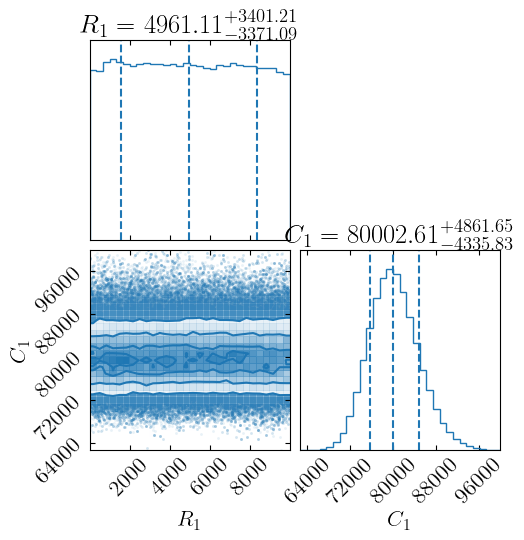

In [31]:
# fig = corner.corner(samples, labels=[r"$R_1$", r"$R_2$",r"$C_1$",r"$C_2$"], color='tab:blue',
#                 show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
#                 plot_density=True,quantiles=[0.16,0.5,0.84])
fig = corner.corner(samples, labels=[r"$R_1$",r"$C_1$"], color='tab:blue',
                show_titles=True, bins=30, plot_contours=True, plot_datapoints=True, 
                plot_density=True,quantiles=[0.16,0.5,0.84])

In [32]:
def running_mean(x, factor=0.01):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))

    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))

    return average


def trace_plotter(samples):
    ndim = samples.shape[1]
    fig, axes = plt.subplots(ndim, figsize=(5, 6), sharex=True)
    labels = [r"$R_1$", r"$R_2$",r"$C_1$",r"$C_2$"]
    mean = running_mean(samples)
    if ndim == 1:
        axes.plot(samples, "tab:blue", alpha=0.7)
        axes.plot(np.arange(len(mean)), mean, color='tab:red')
        axes.tick_params(direction='in')
        axes.set_ylabel('$\\Omega_{M,0}$')
        axes.set_xlabel("step number");
    else:
        for i,ax in zip(range(ndim),axes):
            ax.plot(samples[:, i], "tab:blue", alpha=0.7)
            ax.plot(np.arange(len(mean)), mean[:,i], color='tab:red')
            ax.set_ylabel(labels[i])
            ax.tick_params(direction='in')

        axes[-1].set_xlabel("step number");
    plt.tight_layout()
    #plt.savefig('figs/trace_plot.pdf')
    plt.show()

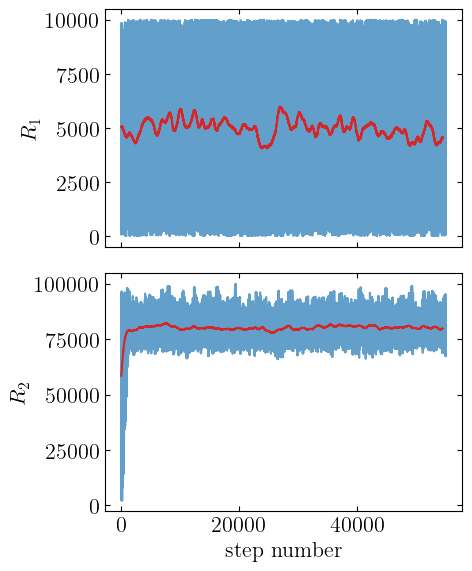

In [33]:
trace_plotter(burned_samples)

Text(0, 0.5, 'Voltage [V]')

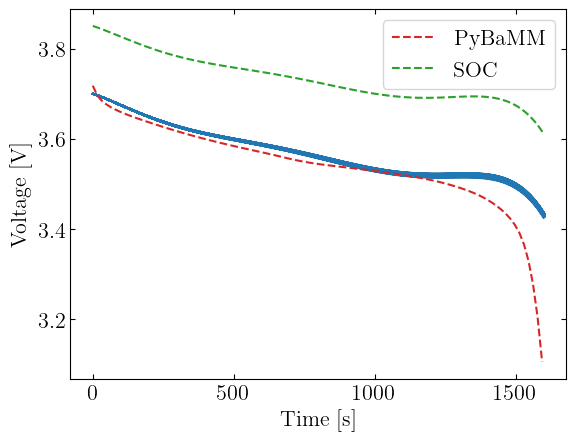

In [39]:
Nsamp = 10000
sample_idx = random.sample(range(0, len(samples)), Nsamp)

t = simulate_II(*samples[0])[0]
for i in sample_idx:
    plt.plot(t,model_II(samples[i]), color='tab:blue', alpha=0.1)
    #plt.plot(t,model(samples[i]), color='tab:blue', alpha=0.1)

#    plt.plot(*simulate_II(*samples[i]), color='tab:blue', alpha=0.1)
plt.plot(*sim_PyBaMM.get_voltage(i0), label = 'PyBaMM', linestyle = '--',color = 'tab:red')
plt.plot(t,V_soc(SOC(i0)), label = 'SOC', linestyle = '--',color = 'tab:green')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Voltage [V]')